In [1]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy  


In [3]:
#Define QID - question matching -- ANES 2020
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}
qids_reverse_coded = ["V201416", "V202234", "V202257", "V202287", "V202332", "V202371"]

def get_counts(path, qids): #function to get a dict with counts for each question
    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 
        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list


In [ ]:
## Test corrected race distributions

#Define QID - question matching
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}


def get_counts_corrected(path, qids): #function to get a dict with counts for each question
    value_list = []

    race_targets = {
        1: 0.7175151626539239,  # White
        2: 0.08968939533174049,  # Black
        3: 0.036206579672854254,  # Asian
        4: 0.021135820621209337,  #  Native/Other 
        5: 0.0880352876309502   # Hispanic
    }

    for id in qids:

        df = pd.read_csv(path + id + ".csv")
        # print(df['V201549x'].value_counts())
        current_counts = df['V201549x'].value_counts().to_dict() 
        # print(current_counts,'current_counts')
        limit = min([current_counts.get(code, 0) / weight for code, weight in race_targets.items()])

        sampled_dfs = []
        for code, weight in race_targets.items():
            n_to_sample = int(limit * weight)
            # Randomly select the correct number of rows for this race
            subset = df[df['V201549x'] == code].sample(n=n_to_sample, random_state=42)
            sampled_dfs.append(subset)

        realistic_df = pd.concat(sampled_dfs).sample(frac=1).reset_index(drop=True)
        df = realistic_df
        # print(df['V201549x'].value_counts().to_dict() ,'current_counts 2')
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 

        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list

In [4]:
def get_human_counts(path, qids): #getting results from anes 2020
     anes_df = pd.read_csv(path)
     human_values = []

     for id in qids:
          human_counts = Counter(anes_df[id].dropna())
          if id in ["V201324", "V202332"]:
               answers = {i: human_counts[i] for i in range(1, 6)}
          else:
               answers = {i: human_counts[i] for i in range(1, 4)}

          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts("../data/2020 ANES_test.csv", qids)

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_22842/2762617278.py:2: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_df = pd.read_csv(path)


In [5]:
#JSD divergence is a more numerically stable version of KL-divergence - better for our case
def jsd_divergence_between_sets(set1, set2, base=2):
    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [40]:
# LLama 3.1 8b
model_name = 'llama8b'
replicate_results = get_counts("../Publication Results/8B-Llama/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/8B-Llama/main_mq_reform_3rdP_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/8B-Llama/Priming/Original/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/8B-Llama/Preamble/Original/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/8B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)

jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}

In [37]:
# LLama 3.1 70b
model_name = 'llama70b'
replicate_results = get_counts("../Publication Results/70B-Llama/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/70B-Llama/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/70B-Llama/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/70B-Llama/main_mq_preamble_results/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/70B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)


jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}


In [28]:
# GPT-4.1
model_name = 'gpt4.1'
# T=0
replicate_results = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_preamble_results/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)


jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}

In [41]:
from copy import deepcopy
def reverse_answers(rever_coded_V2_results):
    rever_coded_V2_results = {list(d.keys())[0]: list(d.values())[0] for d in rever_coded_V2_results}
    rever_coded_V2_results_copy = deepcopy(rever_coded_V2_results)

    rever_coded_V2_results["Gay Marriage"][1] = rever_coded_V2_results_copy["Gay Marriage"][3]
    rever_coded_V2_results["Gay Marriage"][3] = rever_coded_V2_results_copy["Gay Marriage"][1]

    rever_coded_V2_results["Refugee Allowing"][1] = rever_coded_V2_results_copy["Refugee Allowing"][2]
    rever_coded_V2_results["Refugee Allowing"][2] = rever_coded_V2_results_copy["Refugee Allowing"][1]

    rever_coded_V2_results["Income Inequality"][1] = rever_coded_V2_results_copy["Income Inequality"][2]
    rever_coded_V2_results["Income Inequality"][2] = rever_coded_V2_results_copy["Income Inequality"][1]

    rever_coded_V2_results["Gender Role"][1] = rever_coded_V2_results_copy["Gender Role"][2]
    rever_coded_V2_results["Gender Role"][2] = rever_coded_V2_results_copy["Gender Role"][1]

    rever_coded_V2_results["Climate Change"][1] = rever_coded_V2_results_copy["Climate Change"][5]
    rever_coded_V2_results["Climate Change"][2] = rever_coded_V2_results_copy["Climate Change"][4]
    rever_coded_V2_results["Climate Change"][4] = rever_coded_V2_results_copy["Climate Change"][2]
    rever_coded_V2_results["Climate Change"][5] = rever_coded_V2_results_copy["Climate Change"][1]

    rever_coded_V2_results["Race Diversity"][1] = rever_coded_V2_results_copy["Race Diversity"][2]
    rever_coded_V2_results["Race Diversity"][2] = rever_coded_V2_results_copy["Race Diversity"][1]

    rever_coded_V2_results = [{key: value} for key, value in rever_coded_V2_results.items()]
    return rever_coded_V2_results

reversed_results = reverse_answers(reversed_results)
jsd_results_reversed = jsd_divergence_between_sets(human_results, reversed_results, base = 2)
diff_reversed_vs_replicate = {key: (jsd_results_reversed[key] - jsd_results_replicate[key]) for key in jsd_results_reversed.keys()}


In [11]:
# 4 conditions are together [not used]
def plot_replicate_w_condition_stacked(silicon_results_1, silicon_results_2, silicon_results_3, silicon_results_4, jsd_results1, jsd_results2, jsd_results3, jsd_results4, label1, label2, label3, label4, output_path=''):
    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]

    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
    silicon_dict3 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_3}
    silicon_dict4 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_4}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    silicon_colors_1 = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors_2 = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]

    silicon1_stack = []
    silicon2_stack = []
    silicon3_stack = []
    silicon4_stack = []
    jsd1 = []
    jsd2 = []
    jsd3 = []
    jsd4 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        s1_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s2_dist = np.array(list(silicon_dict2[question].values()), dtype=float)
        s3_dist = np.array(list(silicon_dict3[question].values()), dtype=float)
        s4_dist = np.array(list(silicon_dict4[question].values()), dtype=float)

        s1_dist /= s1_dist.sum()
        s2_dist /= s2_dist.sum()
        s3_dist /= s3_dist.sum()
        s4_dist /= s4_dist.sum()

        silicon1_stack.append(s1_dist)
        silicon2_stack.append(s2_dist)
        silicon3_stack.append(s3_dist)
        silicon4_stack.append(s4_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])
        jsd3.append(jsd_results3[question])
        jsd4.append(jsd_results4[question])

    # --- Colors (same as original but consistent) ---
    silicon_colors_3 = silicon_colors_2

    silicon_colors_4 = silicon_colors_2

    fig, ax1 = plt.subplots(figsize=(9, 4.2))
    bar_width = 0.18

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width*1.5-0.015,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width*0.5-0.005,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                hatch='//',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.1,
                label=label2+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    for idx, dist in enumerate(silicon3_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*0.5+0.005,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_3[i],
                hatch='oo',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.1,
                label=label3+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    for idx, dist in enumerate(silicon4_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*1.5+0.015,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_4[i],
                hatch='xx',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.1,
                label=label4+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=30, ha='right')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=2, frameon=False, bbox_to_anchor=(-0.01, 1.22))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x-bar_width*1.5, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label1}'
    )
    ax2.plot(
        x-bar_width*0.5, jsd2,
        color='red', marker='^', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label2}'
    )
    ax2.plot(
        x+bar_width*0.5, jsd3,
        color='green', marker='o', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label3}'
    )
    ax2.plot(
        x+bar_width*1.5, jsd4,
        color='blue', marker='x', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label4}'
    )

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1.01, 1.22),ncol=2)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


gpt4.1


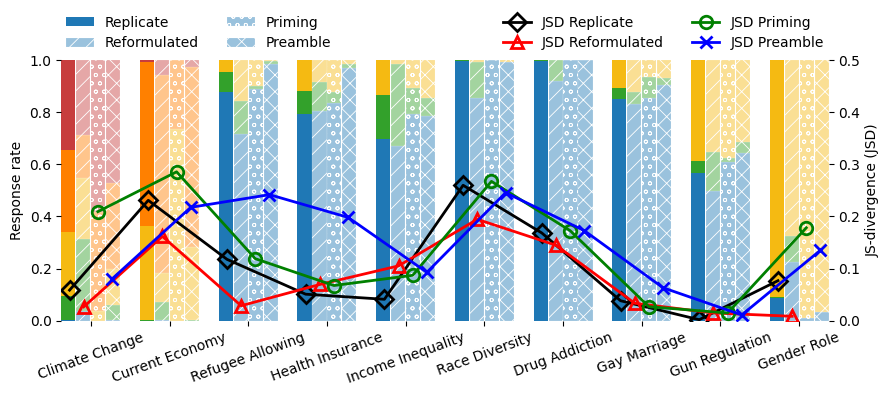

In [ ]:
print(model_name)
plot_replicate_w_condition_stacked(replicate_results, reformulated_results, priming_results, preamble_results, jsd_results_replicate, jsd_results_reformulated, jsd_results_priming, jsd_results_preamble,
              'Replicate', 'Reformulated','Priming','Preamble', '') # do not save

In [ ]:
# replicate + one condition [not used]
def plot_replicate_w_one_condition_stacked(silicon_results_1, silicon_results_2,  jsd_results1, jsd_results2,  label1, label2, output_path=''):
    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]

    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    silicon_colors_1 = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors_2 = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]
    # silicon_colors_2 = silicon_colors_1

    silicon1_stack = []
    silicon2_stack = []
    jsd1 = []
    jsd2 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        s1_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s2_dist = np.array(list(silicon_dict2[question].values()), dtype=float)

        s1_dist /= s1_dist.sum()
        s2_dist /= s2_dist.sum()

        silicon1_stack.append(s1_dist)
        silicon2_stack.append(s2_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])

    fig, ax1 = plt.subplots(figsize=(6.6, 3.8))
    bar_width = 0.33

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width*0.5,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*0.5,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                # hatch='//',                 # ★ ADD THIS ★
                # edgecolor='white',
                linewidth=0.0,
                label=label2+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val
 
    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=20, ha='center')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=1, frameon=False, bbox_to_anchor=(-0.01, 1.22))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x-bar_width*0.5, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label1}'
    )
    ax2.plot(
        x+bar_width*0.5, jsd2,
        color='red', marker='^', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label2}'
    )

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1.01, 1.22),ncol=1)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


llama70b


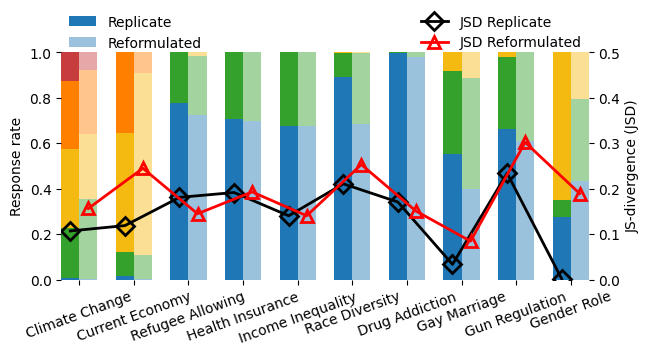

In [473]:
print(model_name)
plot_replicate_w_one_condition_stacked(replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated,
              'Replicate', 'Reformulated', '')

In [14]:
# replicate + two condition
def plot_replicate_w_two_condition_stacked(silicon_results_1, silicon_results_2, silicon_results_3, jsd_results1, jsd_results2, label1, label2, label3, output_path=''):
    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]
    if label3 == 'Reverse-coded':
        categories = [
            'Climate Change','Refugee Allowing', 
        'Income Inequality', 'Race Diversity',
        'Gay Marriage', 'Gender Role'
        ]
    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
    silicon_dict3 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_3}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    silicon_colors_1 = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors_2 = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]
    # silicon_colors_2 = silicon_colors_1

    silicon1_stack = []
    silicon2_stack = []
    silicon3_stack = []
    silicon4_stack = []
    jsd1 = []
    jsd2 = []
    jsd3 = []
    jsd4 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        s1_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s2_dist = np.array(list(silicon_dict2[question].values()), dtype=float)
        s3_dist = np.array(list(silicon_dict3[question].values()), dtype=float)

        s1_dist /= s1_dist.sum()
        s2_dist /= s2_dist.sum()
        s3_dist /= s3_dist.sum()

        silicon1_stack.append(s1_dist)
        silicon2_stack.append(s2_dist)
        silicon3_stack.append(s3_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])
        # jsd3.append(jsd_results3[question])

    # --- Colors (same as original but consistent) ---
    silicon_colors_3 = silicon_colors_1
    silicon_colors_3 = [
    (0.12, 0.47, 0.71, 0.725),
    (0.20, 0.63, 0.17, 0.725),
    (0.96, 0.73, 0.07, 0.725),
    (1.00, 0.50, 0.00, 0.725),
    (0.78, 0.24, 0.24, 0.725),
]

    # fig, ax1 = plt.subplots(figsize=(6.6, 3.8))
    fig, ax1 = plt.subplots(figsize=(6.6, 4))
    bar_width = 0.25

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*0,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                # hatch='//',                 # ★ ADD THIS ★
                # edgecolor='white',
                linewidth=0.0,
                label=label2+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    for idx, dist in enumerate(silicon3_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_3[i],
                hatch='oo',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.0,
                label=label3+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

  
    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=35, ha='right')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=2, frameon=False, bbox_to_anchor=(0, 1.25))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x+bar_width*0, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label2}'
    )
    ax2.plot(
        x+bar_width, jsd2,
        color='red', marker='o', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label3}'
    ) 

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1.0, 1.25),ncol=1)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    plt.rcParams['hatch.linewidth'] = 0.6  # previous pdf hatch linewidth

    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


gpt4.1
Saved figure to gpt4.1-2cond-reformulated.pdf


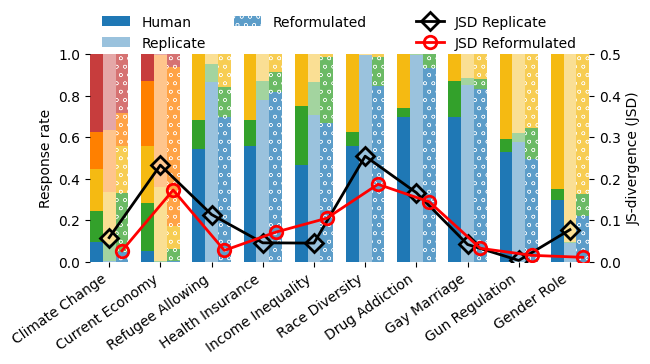

In [30]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results,replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated,
              'Human', 'Replicate', 'Reformulated', 'gpt4.1-2cond-reformulated.pdf')
# llama8b-2cond-reformulated.pdf

llama70b
Saved figure to llama70b-2cond-priming.pdf


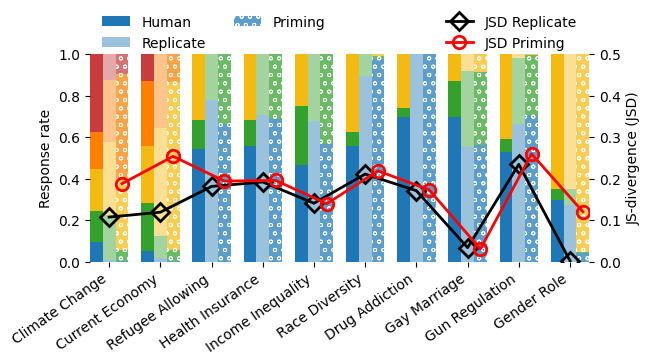

In [38]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results, replicate_results, priming_results, jsd_results_replicate, jsd_results_priming,
              'Human', 'Replicate', 'Priming', 'llama70b-2cond-priming.pdf')
# llama8b-2cond-priming.pdf

llama70b
Saved figure to llama70b-2cond-preamble.pdf


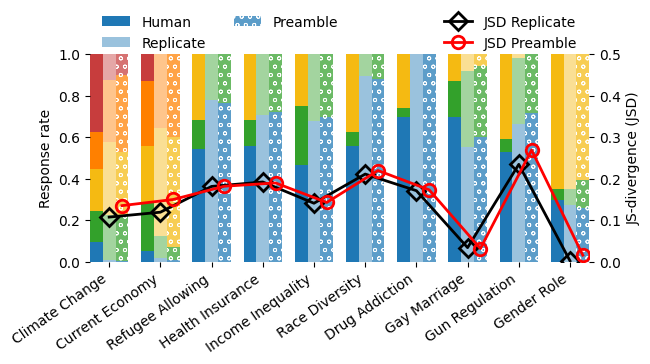

In [39]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results, replicate_results, preamble_results, jsd_results_replicate, jsd_results_preamble,
              'Human', 'Replicate', 'Preamble', 'llama70b-2cond-preamble.pdf')
# llama8b-2cond-priming.pdf

In [42]:
def plot_replicate_w_two_condition_stacked_reversed(silicon_results_1, silicon_results_2, silicon_results_3, jsd_results1, jsd_results2, label1, label2, label3, output_path=''):
    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]
    if label3 == 'Reverse-coded':
        categories = [
            'Climate Change','Refugee Allowing', 
        'Income Inequality', 'Race Diversity',
        'Gay Marriage', 'Gender Role'
        ]
    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
    silicon_dict3 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_3}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    silicon_colors_1 = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors_2 = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]

    silicon1_stack = []
    silicon2_stack = []
    silicon3_stack = []
    jsd1 = []
    jsd2 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        s1_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s2_dist = np.array(list(silicon_dict2[question].values()), dtype=float)
        s3_dist = np.array(list(silicon_dict3[question].values()), dtype=float)

        s1_dist /= s1_dist.sum()
        s2_dist /= s2_dist.sum()
        s3_dist /= s3_dist.sum()

        silicon1_stack.append(s1_dist)
        silicon2_stack.append(s2_dist)
        silicon3_stack.append(s3_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])

    # --- Colors (same as original but consistent) ---
    silicon_colors_3 = silicon_colors_1
    silicon_colors_3 = [
    (0.12, 0.47, 0.71, 0.725),
    (0.20, 0.63, 0.17, 0.725),
    (0.96, 0.73, 0.07, 0.725),
    (1.00, 0.50, 0.00, 0.725),
    (0.78, 0.24, 0.24, 0.725),
]

    # fig, ax1 = plt.subplots(figsize=(6.6, 3.8))
    fig, ax1 = plt.subplots(figsize=(5.2, 4.4))
    bar_width = 0.25

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*0,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                # hatch='//',                 # ★ ADD THIS ★
                # edgecolor='white',
                linewidth=0.0,
                label=label2+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    for idx, dist in enumerate(silicon3_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_3[i],
                hatch='oo',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.0,
                label=label3+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=35, ha='right')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=1, frameon=False, bbox_to_anchor=(0, 1.32))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x+bar_width*0+0.02, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label2}'
    )
    ax2.plot(
        x+bar_width+0.04, jsd2,
        color='red', marker='o', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label3}'
    )

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.88)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1, 1.27),ncol=1)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    plt.rcParams['hatch.linewidth'] = 0.3  # previous pdf hatch linewidth

    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


llama8b
Saved figure to llama8b-2cond-reversed.pdf


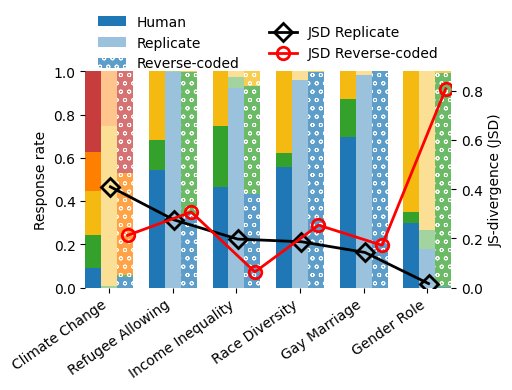

In [43]:
print(model_name)
plot_replicate_w_two_condition_stacked_reversed(human_results, replicate_results, reversed_results, jsd_results_replicate, jsd_results_reversed,
              'Human', 'Replicate', 'Reverse-coded', 'llama8b-2cond-reversed.pdf')
